In [1]:
#%%
%load_ext autoreload
%autoreload 2

# How similar are model predictions?

Looking at 0-shot predictions, how similar are the answers that models provide?

In [48]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
import itertools
from functools import partial
from pathlib import Path

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS, LLM_MODELS
from monoculture.analysis.utils import (
    key_to_model,
    get_metrics,
    load_risk_scores,
    prettify_model_name,
    sort_by_size_and_family,
    get_size_and_it,
)
from monoculture.analysis.plotting import plot_agreement_matrix,plot_model_agreement_barplot
from monoculture.analysis.metrics import (
    get_observed_pairwise_agreement,
    get_pairwise_neg_agreement,
    get_pairwise_pos_agreement,
    expected_pairwise_agreement,
    matrix_pairwise_evals,
)
import folktexts
from folktexts import ACSDataset, ACSTaskMetadata
from folktexts.ts import TableshiftBRFSSTaskMetadata, TableshiftBRFSSDataset


In [64]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/"

tasks ('ACSIncome', 'ACSEmployment', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


### Load 0-shot risk scores

In [4]:
df_overview = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_overview = df_overview[
    (df_overview["num_shots"] == 0)
    & (df_overview["prompt_style"] == "bullet")
    & (df_overview["prompt_connector"] == "is")
    & (df_overview["threshold_fitted"] == 1)
]
df_overview.head()

,task,model,is_inst,threshold_fitted,bench_hash,num_shots,prompt_style,prompt_connector,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,3019759728,0,bullet,is,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,3118177042,0,bullet,is,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,3621160589,0,bullet,is,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,1712994131,0,bullet,is,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,4121241683,0,bullet,is,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [5]:
list(df_overview["task"].unique())

['ACSIncome',
 'ACSEmployment',
 'ACSTravelTime',
 'ACSPublicCoverage',
 'BRFSS_Diabetes',
 'BRFSS_Blood_Pressure']

In [6]:
# load predictions and some evaluation metrics
risk_scores_0 = {}  # format: scores[task] --> pd.DataFrame
evals_0 = {}  # format: evals[task][model][metric] --> float

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
    "threshold",

]

for task in TASKS:
    task_df = df_overview[(df_overview["task"] == task)]

    # available models
    models = task_df["model"].unique().tolist()
    models.sort(key=get_size_and_it)

    risk_scores_per_task = []
    evals_0[task] = {}

    for m in models:
        data_m = task_df[task_df["model"] == m]
        assert (
            data_m.shape[0] == 1
        ), f"Expected 1 row for model {m} but found {data_m.shape[0]}\m{data_m}"
        evals_0[task][m] = get_metrics(
            data_m.iloc[0]["eval_results_path"], metrics=metrics
        )
        risk_scores_per_task.append(
            load_risk_scores(data_m.iloc[0]["predictions_path"])
        )
    risk_scores_0[task] = pd.concat(risk_scores_per_task, axis=1)

### Utility functions

In [7]:
def binarize_using_threshold(col, evals: dict):
    m = col.name
    return col > evals[m]["threshold"]


def risk_score_to_prediction(risk_scores: pd.DataFrame, binarize_fun=lambda x: x > 0.5):
    return risk_scores.apply(binarize_fun, axis=0).astype(int)
    #     return risk_scores[task].apply(partial(binarize_using_threshold, evals=evals[task]), axis=0).astype(int)
    # else:
    #     return (risk_scores[task]>0.5).astype(int)


def observed_agreement_wrapper(
    m1: str, m2: str, predictions: pd.DataFrame, fun=get_observed_pairwise_agreement
):
    assert (m1 in predictions.columns) & (
        m2 in predictions.columns
    ), "Both models must be present as column in predictions"

    return fun(
        predictions[m1],
        predictions[m2],
    )


def ratio_wrapper(m1, m2, predictions, evals, metric="accuracy"):
    assert (m1 in predictions.columns) & (
        m2 in predictions.columns
    ), "Both models must be present as column in predictions"

    observed = get_observed_pairwise_agreement(predictions[m1], predictions[m2])
    expected = expected_pairwise_agreement(
        evals[m1][metric],
        evals[m2][metric],
    )
    return observed / expected

def diff_wrapper(m1, m2, predictions, evals, metric="accuracy"):
    assert (m1 in predictions.columns) & (
        m2 in predictions.columns
    ), "Both models must be present as column in predictions"

    observed = get_observed_pairwise_agreement(predictions[m1], predictions[m2])
    expected = expected_pairwise_agreement(
        evals[m1][metric],
        evals[m2][metric],
    )
    return observed - expected

In [ ]:
def agreement_line_plot(
    ax,
    agreements_observed: torch.Tensor | np.ndarray,
    agreements_exp: torch.Tensor | np.ndarray,
    sort_by=None,
    title="",
):
    if isinstance(agreements_observed, torch.Tensor): 
        agreements_observed = agreements_observed.numpy()
    if isinstance(agreements_exp, torch.Tensor): 
        agreements_exp = agreements_exp.numpy()
    if sort_by:
        assert sort_by in [
            "observed",
            "expected",
        ], "If provided, 'sort_by' has to be one of ['observed', 'expected']."
        if sort_by == "obs":
            sort_indices = np.argsort(agreements_observed)
        elif sort_by == "exp":
            sort_indices = np.argsort(agreements_exp)
        agreements_observed = agreements_observed[sort_indices]
        agreements_exp = agreements_exp[sort_indices]
    else:
        agreements_observed = sorted(agreements_observed)
        agreements_exp = sorted(agreements_exp)
    
    fraction_model_pairs = np.arange(len(agreements_observed))/len(agreements_observed)
    ax.plot(fraction_model_pairs, np.ones_like(agreements_observed), label='monoculture', color='red')
    ax.plot(fraction_model_pairs, agreements_observed, label="observed")
    ax.plot(fraction_model_pairs, agreements_exp, label="random error")
    ax.plot(fraction_model_pairs, np.zeros_like(agreements_observed)+0.5, label='chance level', color='grey', linestyle='dashed', linewidth=1, zorder=-1)
    ax.fill_between(fraction_model_pairs, agreements_observed, np.ones_like(agreements_observed), color='lightgrey', alpha=0.4)
    ax.set_ylim(bottom=0, top=1.01)
    ax.set_title(title.replace('ACS', 'ACS ').replace('_', ' '))
    return ax

### Get predictions

In [9]:
predictions = {}
for task in TASKS:
    predictions[task] = risk_score_to_prediction(risk_scores_0[task], binarize_fun=partial(binarize_using_threshold, evals=evals_0[task]))

In [10]:
predictions['ACSIncome'][sort_by_size_and_family(predictions['ACSIncome'].columns)].head()

,meta-llama--Meta-Llama-3.2-1B,meta-llama--Meta-Llama-3.2-1B-Instruct,meta-llama--Meta-Llama-3.2-3B,meta-llama--Meta-Llama-3.2-3B-Instruct,meta-llama--Meta-Llama-3-8B,meta-llama--Meta-Llama-3.1-8B,meta-llama--Meta-Llama-3-8B-Instruct,meta-llama--Meta-Llama-3.1-8B-Instruct,meta-llama--Meta-Llama-3-70B,meta-llama--Meta-Llama-3.1-70B,...,Qwen--Qwen2.5-7B-Instruct,Qwen--Qwen2-7B-Instruct,Qwen--Qwen2.5-72B,Qwen--Qwen2-72B,Qwen--Qwen2.5-72B-Instruct,Qwen--Qwen2-72B-Instruct,01-ai--Yi-6B,01-ai--Yi-6B-Chat,01-ai--Yi-34B,01-ai--Yi-34B-Chat
238351,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2995677,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2360043,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1924596,1,0,1,1,0,1,0,1,1,1,...,1,1,0,0,0,0,0,1,0,0
2803585,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### How often do models agree in a prediction? (all models, all individuals)

#### General Agreement

How often do models agree in the predictions they make? 
- **Note**: models that are more accuracte are also more likely to agree just by random chance
- We can correct for it
    - by deviding: report the factor by which the observation deviated
    - by substracting: report absolute deviation of observed from expected 
- When risk scores are turned into predictions not by their fitted threshold, but by cutting of at 0.5, we observe that in particular smaller models agree a lot, mainly because they are (almost) constant predictors. This highlights, that a deeper look into a model's behaviour is needed to explain the agreement rates (take model behavior into account). 

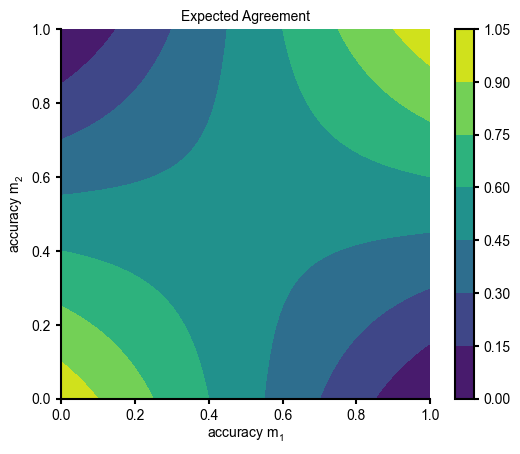

In [11]:
fun = lambda a1,a2: a1*a2 + (1-a1)*(1-a2)
vals = np.arange(0,1.01, step=0.01)
xs, ys = np.meshgrid(vals,vals)
zs = xs*ys + (1-xs)*(1-ys)
plt.contourf(vals, vals, zs)
plt.axis('scaled')
plt.xlabel('accuracy $m_1$'); plt.ylabel('accuracy $m_2$'); plt.title('Expected Agreement')
plt.colorbar()
plt.show()
# cut-through
# plt.plot(vals, [fun(v,1-v) for v in vals])

##### Agreement Matrices

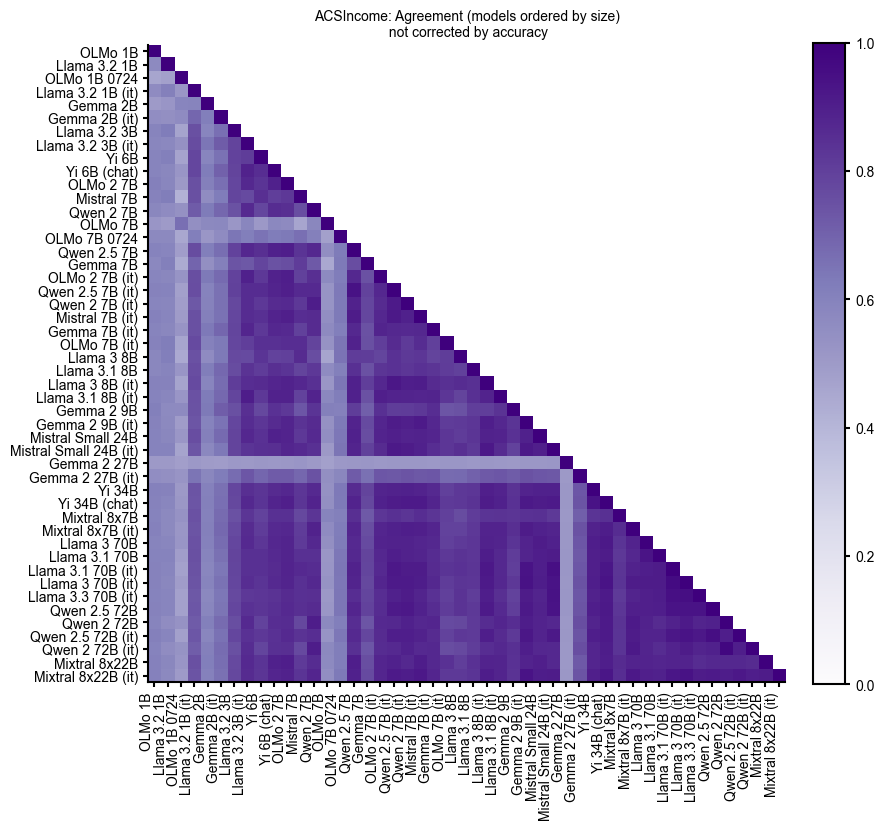

min: 0.42	max: 1.00


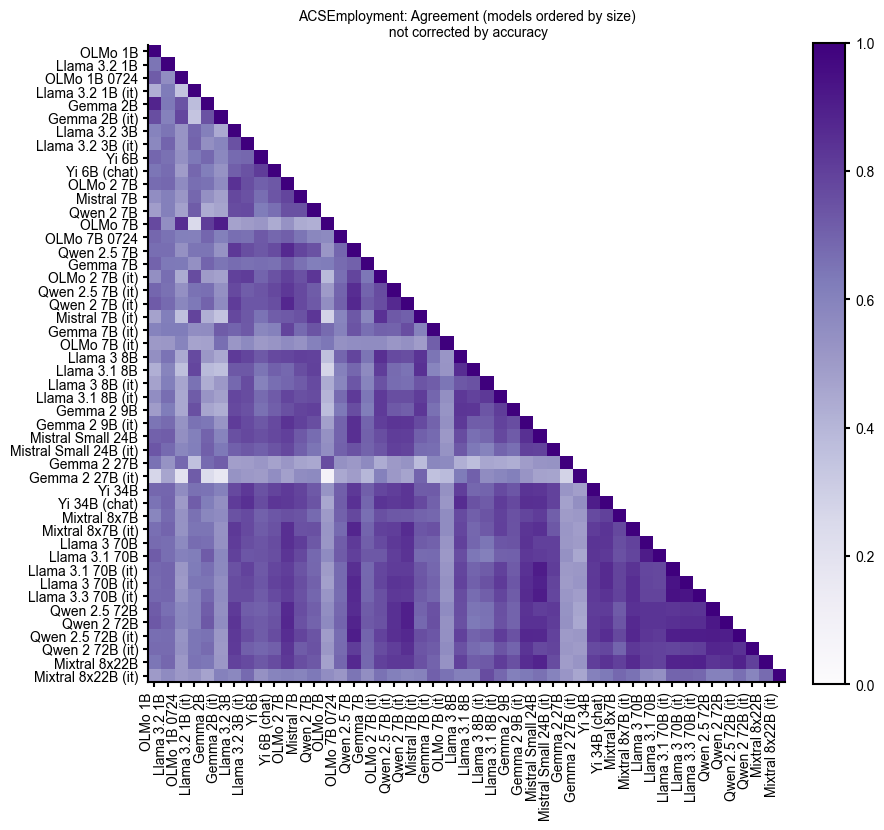

min: 0.07	max: 1.00


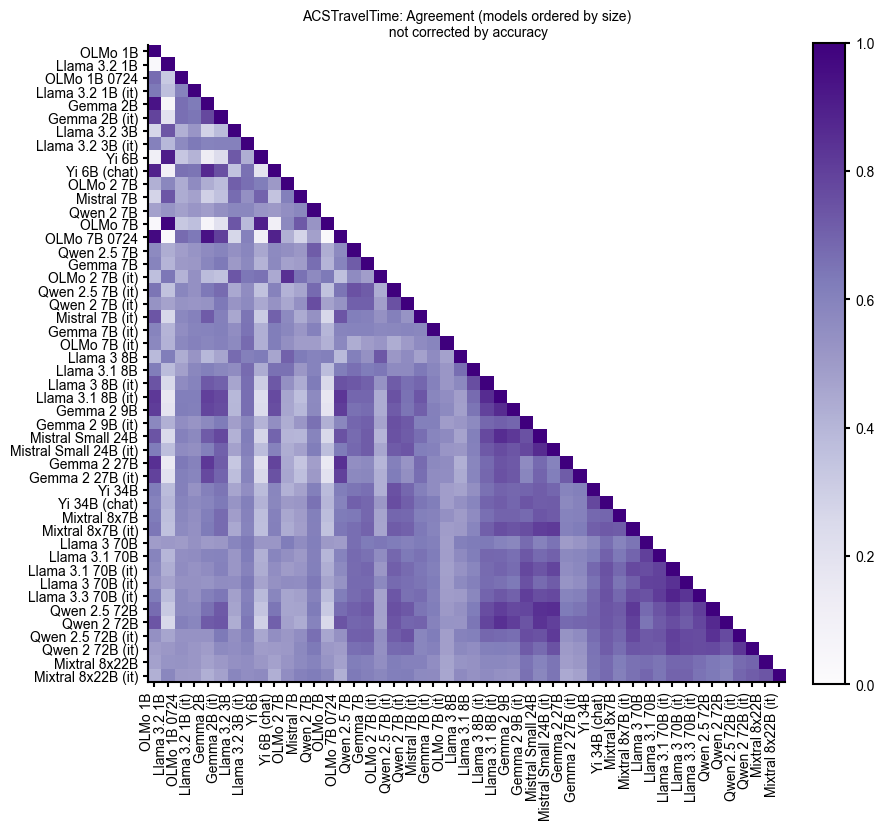

min: 0.02	max: 1.00


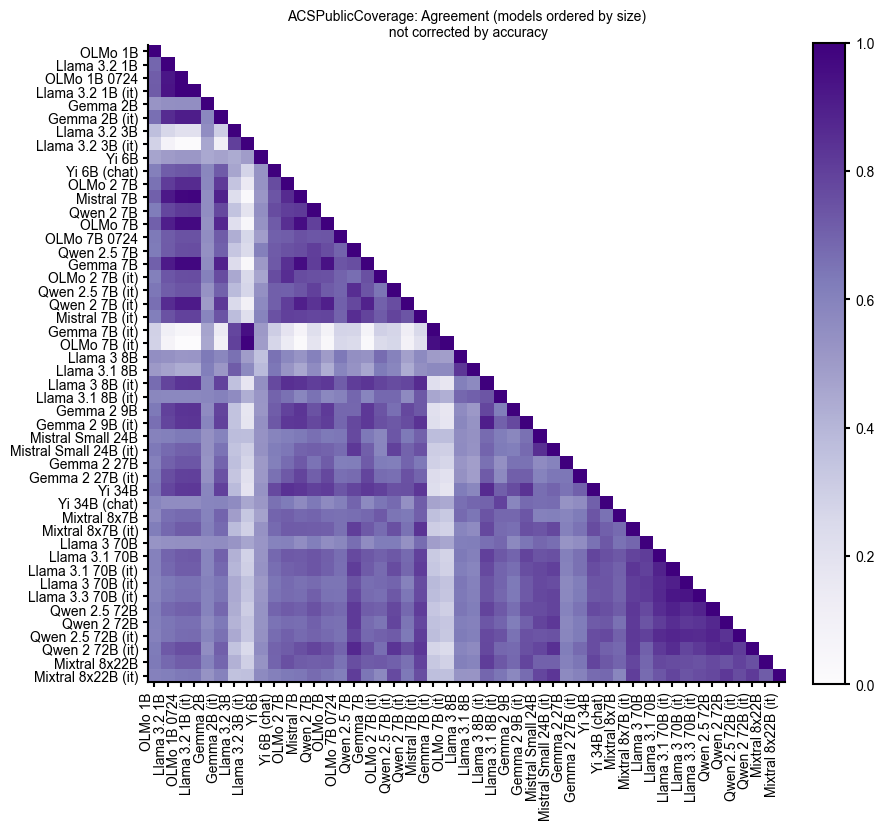

min: 0.00	max: 1.00


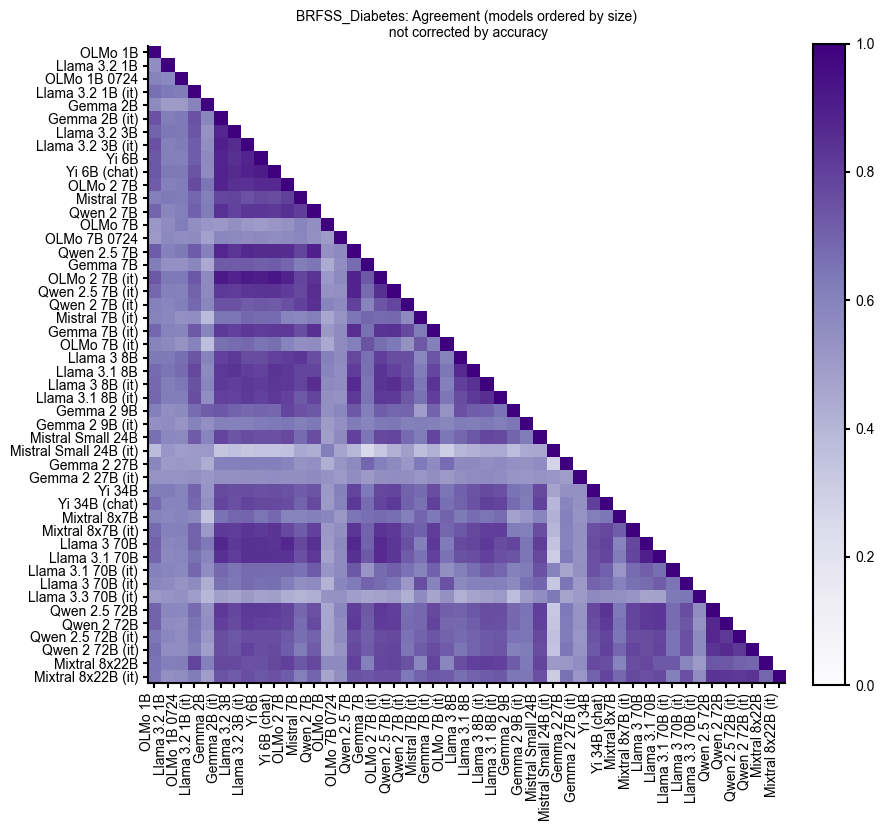

min: 0.25	max: 1.00


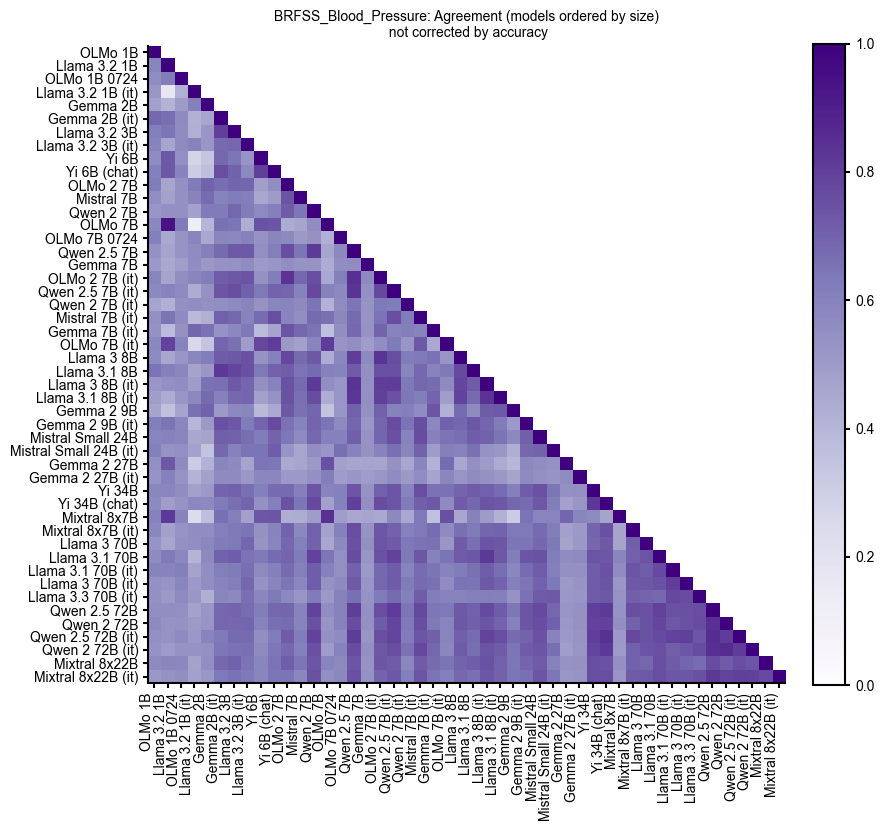

min: 0.12	max: 1.00


In [12]:
# agreement not corrected by accuracy
# 1 = full agreement, 0 = no agreement/exaclty opposite, midpoint unclear, thus unicolor
for task in TASKS:
    models_sorted = sorted(predictions[task].columns, key=get_size_and_it)
    agreement_matrix = matrix_pairwise_evals(models_sorted, partial(observed_agreement_wrapper, predictions=predictions[task]))

    cmap_bound = max(abs(agreement_matrix[~agreement_matrix.isnan()].min()), abs(agreement_matrix[~agreement_matrix.isnan()].max()))
    plot_agreement_matrix(
        models_sorted,
        agreement_matrix,
        cmap="Purples",
        title=f"{task}: Agreement (models ordered by size)\n not corrected by accuracy",
        figsize=(9,9),
        annotate=False, 
    )
    print(f"min: {agreement_matrix[~agreement_matrix.isnan()].min():.2f}\tmax: {agreement_matrix[~agreement_matrix.isnan()].max():.2f}")

When calculating the ratio between the observed agreement and what we would expect given the accuracy of each model (i.e. assuming models make their errors at random), we see that model predictions, especially for smaller models are much more aligned than what we would expect at random. 
- values close to 1 mean that model agreement is on a level close to what we would expect at random
- dark blue cells indicate that model pairs agree much less than what would be expected at random (anti-correlated?)
- dark red cells indicate that model pairs agree much more than random

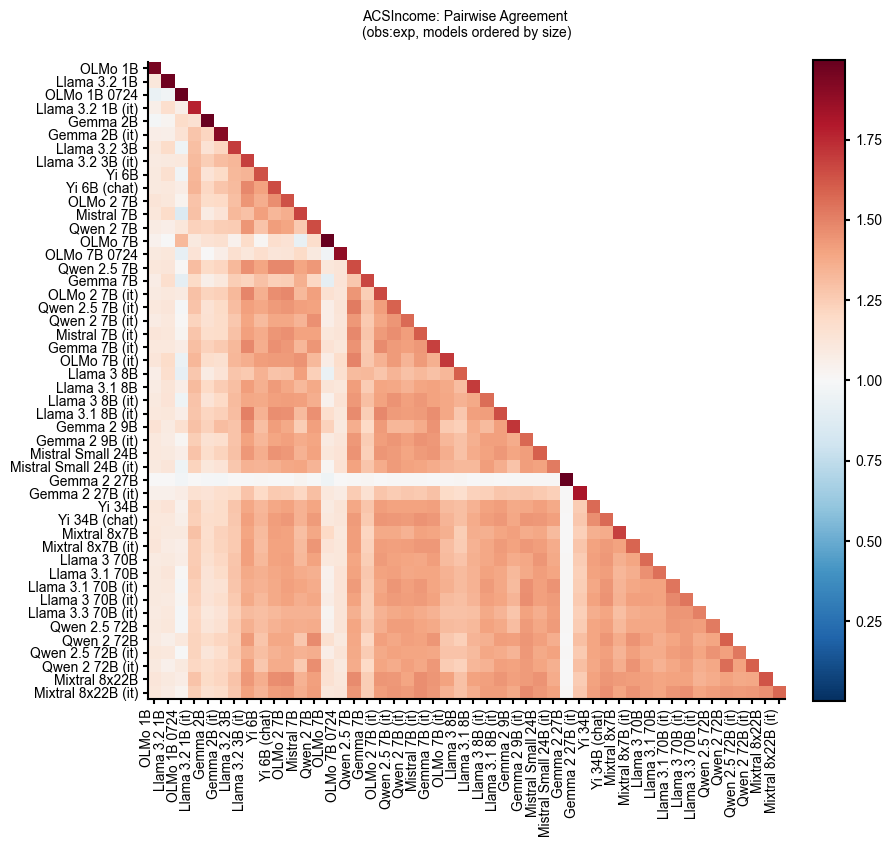

min: 0.86	max: 2.00	median: 1.34


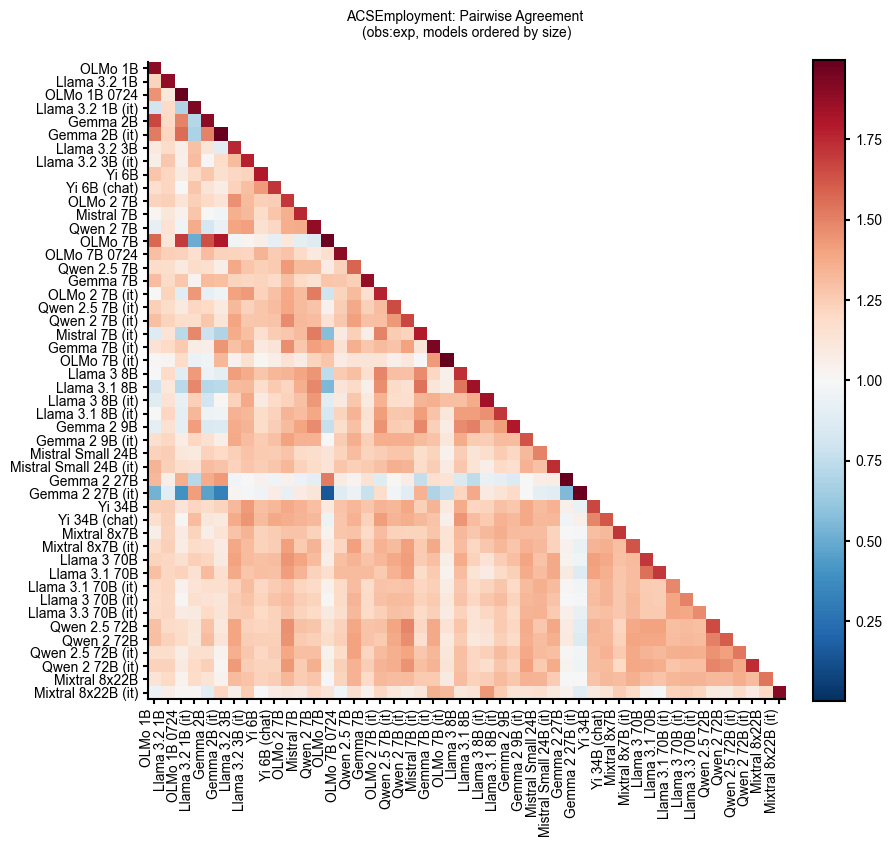

min: 0.15	max: 2.00	median: 1.25


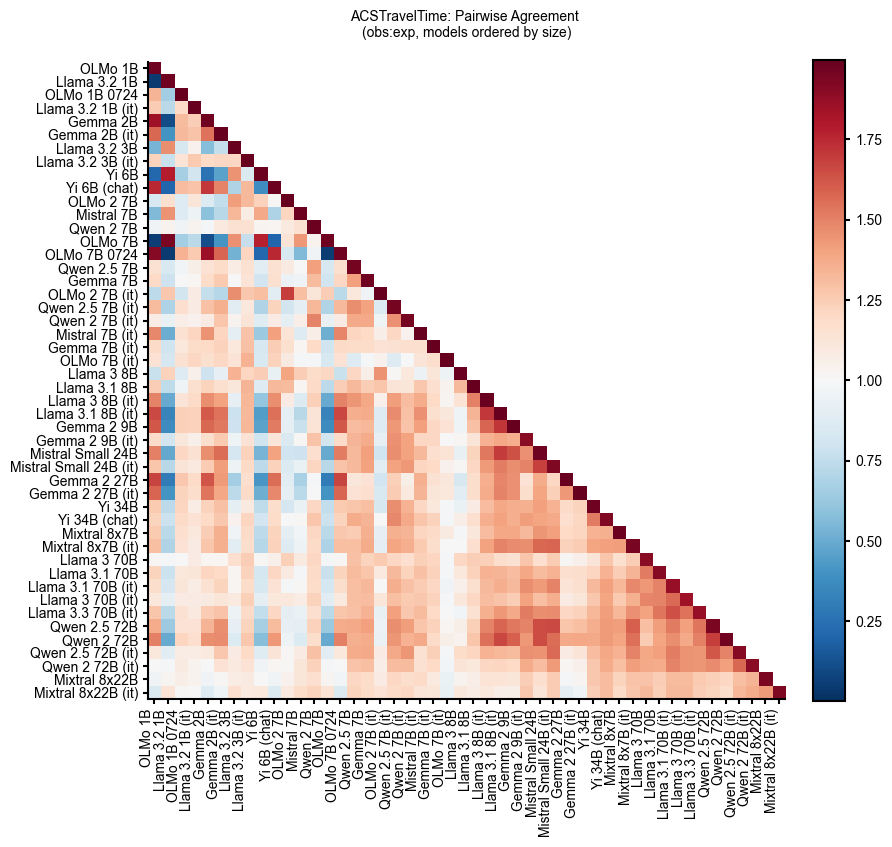

min: 0.04	max: 2.00	median: 1.20


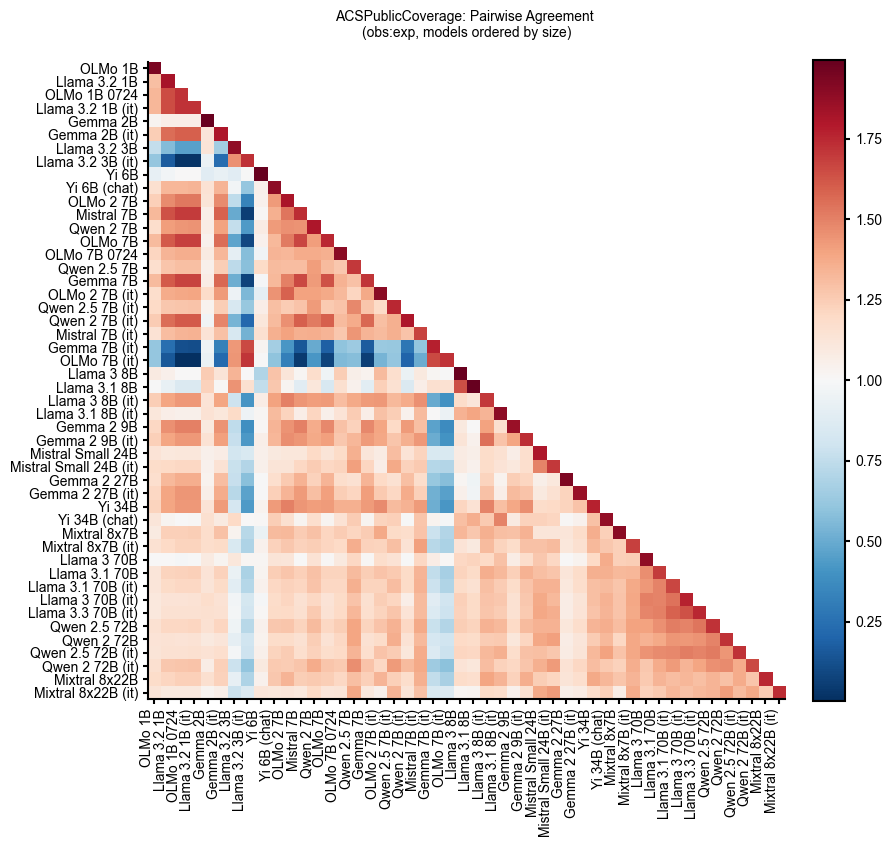

min: 0.00	max: 2.00	median: 1.22


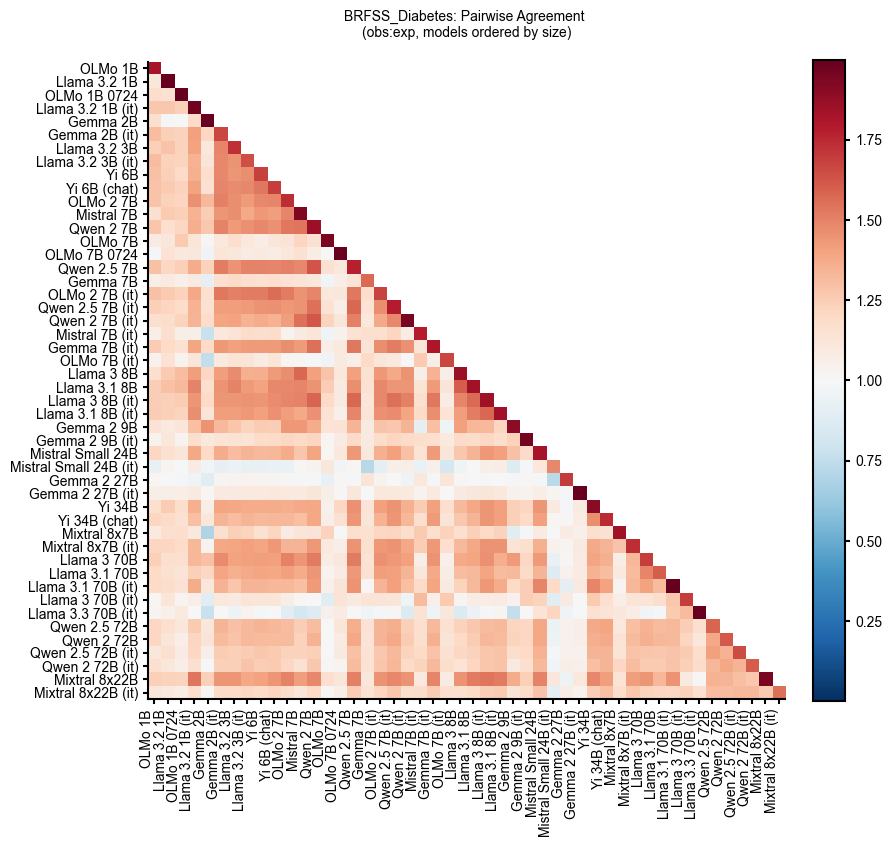

min: 0.70	max: 2.00	median: 1.22


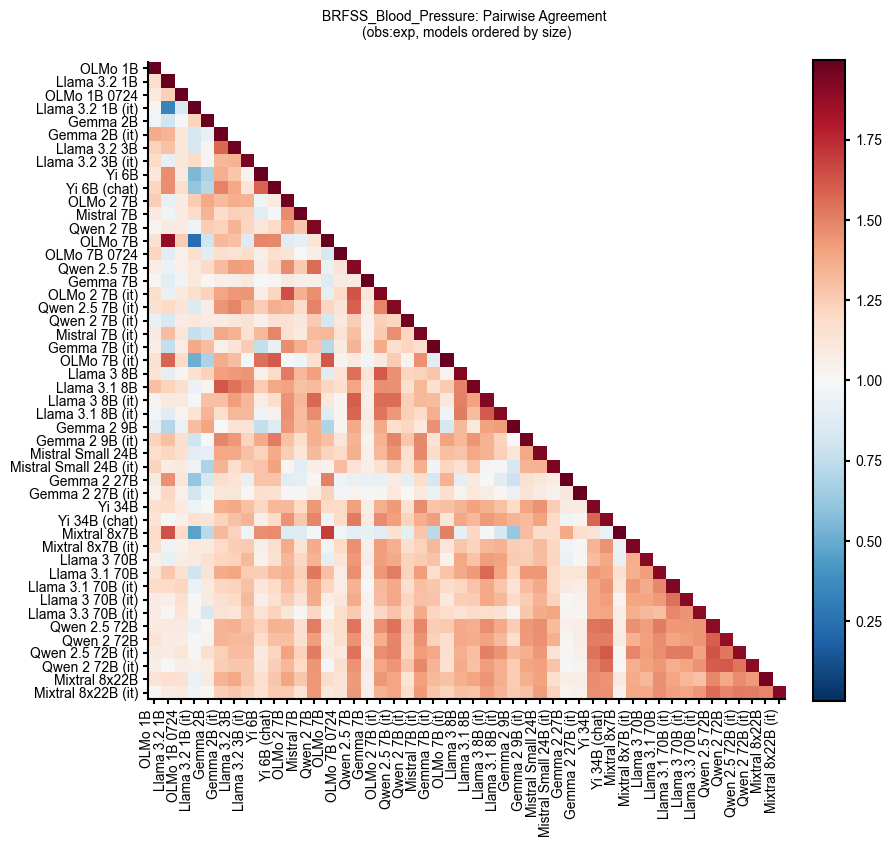

min: 0.24	max: 2.00	median: 1.23


In [13]:
# ratio 
for task in TASKS:
    models_sorted = sorted(predictions[task].columns, key=get_size_and_it)
    agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(ratio_wrapper, predictions=predictions[task], evals=evals_0[task]),
    )

    cmap_bound = max(
        abs(agreement_matrix[~agreement_matrix.isnan()].min()),
        abs(agreement_matrix[~agreement_matrix.isnan()].max()),
    )
    diff_to_1 = 1 - cmap_bound
    plot_agreement_matrix(
        models_sorted,
        agreement_matrix,
        cmap="RdBu_r",
        title=f"{task}: Pairwise Agreement \n(obs:exp, models ordered by size)\n",
        figsize=(9,9),
        annotate=False,
        vmin=1 - diff_to_1, 
        vmax=1 + diff_to_1,
    )
    print(
        f"min: {agreement_matrix[~agreement_matrix.isnan()].min():.2f}\tmax: {agreement_matrix[~agreement_matrix.isnan()].max():.2f}\tmedian: {agreement_matrix[~agreement_matrix.isnan()].median():.2f}"
    )

When calculating the difference between the observed and expected agreement, we see that model predictions tend to be more aligned than what we would expect at random. 
- values close to 0 mean that model agreement is on a level close to what we would expect at random
- dark blue cells indicate that model pairs agree much less than what would be expected at random (anti-correlated?)
- dark red cells indicate that model pairs agree much more than random

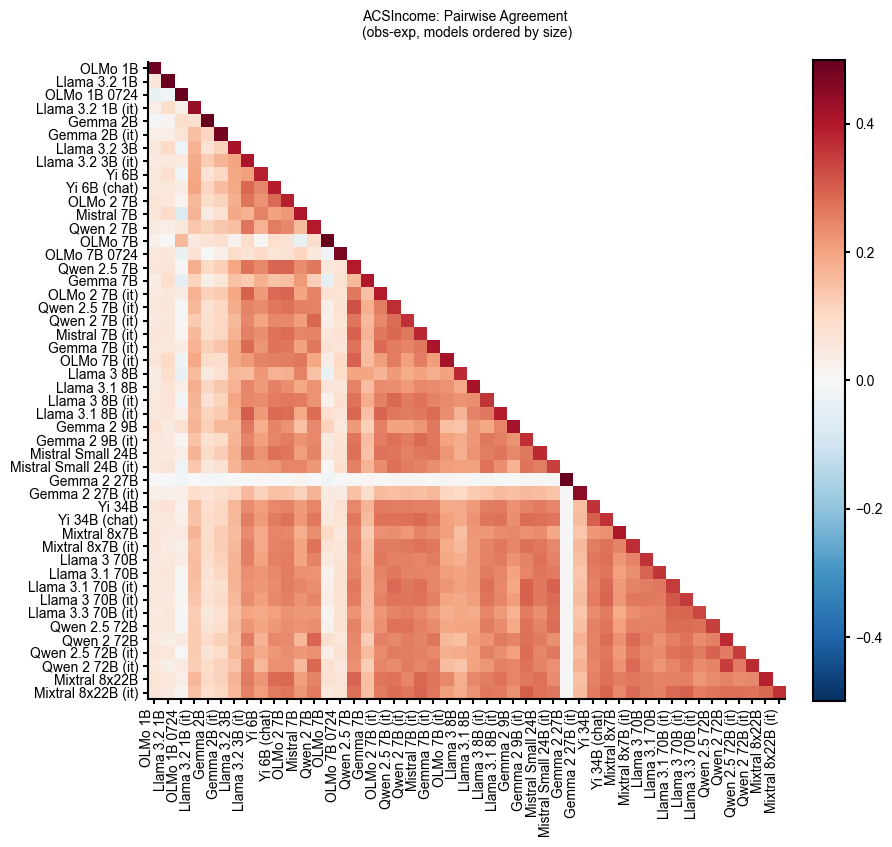

min: -0.07	max: 0.50	median: 0.21


In [14]:
# diff 
for task in ['ACSIncome']:
    models_sorted = sorted(predictions[task].columns, key=get_size_and_it) #sort_by_size_and_family(predictions[task].columns) #
    agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(diff_wrapper, predictions=predictions[task], evals=evals_0[task]),
    )

    cmap_bound = max(
        abs(agreement_matrix[~agreement_matrix.isnan()].min()),
        abs(agreement_matrix[~agreement_matrix.isnan()].max()),
    )
    plot_agreement_matrix(
        models_sorted,
        agreement_matrix,
        cmap="RdBu_r",
        title=f"{task}: Pairwise Agreement \n(obs-exp, models ordered by size)\n",
        figsize=(9,9),
        annotate=False,
        vmin=-cmap_bound, 
        vmax=cmap_bound,
    )
    print(
        f"min: {agreement_matrix[~agreement_matrix.isnan()].min():.2f}\tmax: {agreement_matrix[~agreement_matrix.isnan()].max():.2f}\tmedian: {agreement_matrix[~agreement_matrix.isnan()].median():.2f}"
    )

In [15]:
print("Likelihood to predict 1:")
for m in sorted(predictions['ACSIncome'].columns, key=get_size_and_it)[:13]:
    print(
        f"- {prettify_model_name(key_to_model(m)):<25}{predictions['ACSIncome'][m].sum()/predictions['ACSIncome'].shape[0]:.3f}"
    )
# get_observed_pairwise_agreement(
#     predictions['ACSIncome']["meta-llama--Meta-Llama-3.2-1B"], predictions['ACSIncome']["allenai--OLMo-1B-hf"]
# )

Likelihood to predict 1:
- OLMo 1B                  0.431
- Llama 3.2 1B             0.372
- OLMo 1B 0724             0.700
- Llama 3.2 1B (it)        0.448
- Gemma 2B                 0.638
- Gemma 2B (it)            0.576
- Llama 3.2 3B             0.398
- Llama 3.2 3B (it)        0.542
- Yi 6B                    0.401
- Yi 6B (chat)             0.514
- OLMo 2 7B                0.486
- Mistral 7B               0.331
- Qwen 2 7B                0.544


##### Lineplot: Model Agreements Obs vs. Expected
*inspired by Mania et al. Fig 1a*

Sort model pairs by their agreement and plot the observed and expected model agreement

**Note:** obs and exp are sorted independently, thus there is not 1:1-correspondence between points at the same x (change by settiong sort_by to 'obs' or 'exp')

In [16]:
N = predictions['ACSIncome'].shape[0]
(torch.randint(low=0, high=2, size=(N,)) == torch.randint(low=0, high=2, size=(N,))).sum()/N

tensor(0.5009)

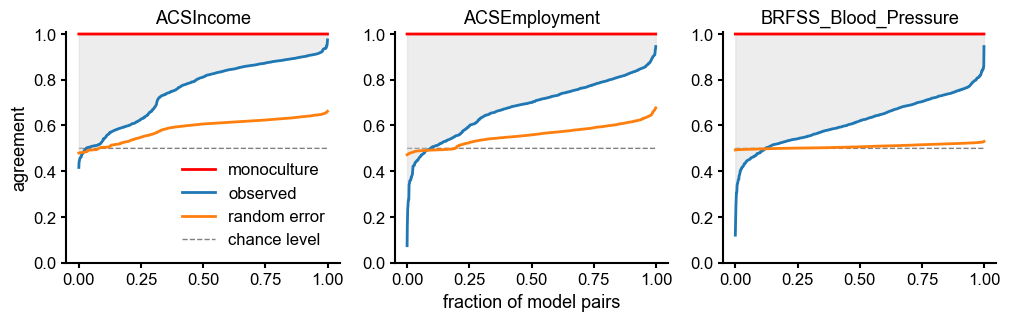

In [74]:
tasks_to_plot = ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']
fig, axs = plt.subplots(1, len(tasks_to_plot), figsize=(4 * len(tasks_to_plot), 3))
sort_by = None
for i, task in enumerate(tasks_to_plot):
    models_sorted = sorted(predictions[task].columns, key=get_size_and_it)
    M = len(models_sorted)

    # agreements without diagonal
    obs_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(observed_agreement_wrapper, predictions=predictions[task]),
    ).fill_diagonal_(torch.nan)
    exp_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        fun=lambda m1, m2: expected_pairwise_agreement(
            evals_0[task][m1]["accuracy"], evals_0[task][m2]["accuracy"]
        ),
    ).fill_diagonal_(torch.nan)

    axs[i] = agreement_line_plot(axs[i], 
                                 obs_agreement_matrix[~obs_agreement_matrix.isnan()], 
                                 exp_agreement_matrix[~exp_agreement_matrix.isnan()], 
                                 title=task)
axs[0].legend()
axs[0].set_ylabel("agreement")
axs[1].set_xlabel("fraction of model pairs")
# fig.suptitle('Pairwise agreement')
plt.savefig('/Users/mgorecki/Documents/2025-04-SAB-meeting/figures/agreement_all.png')
plt.show()

#### Agreement on negative predictions

When we only look at negative predictions (irrespective of whether these are correct or not), we can see 

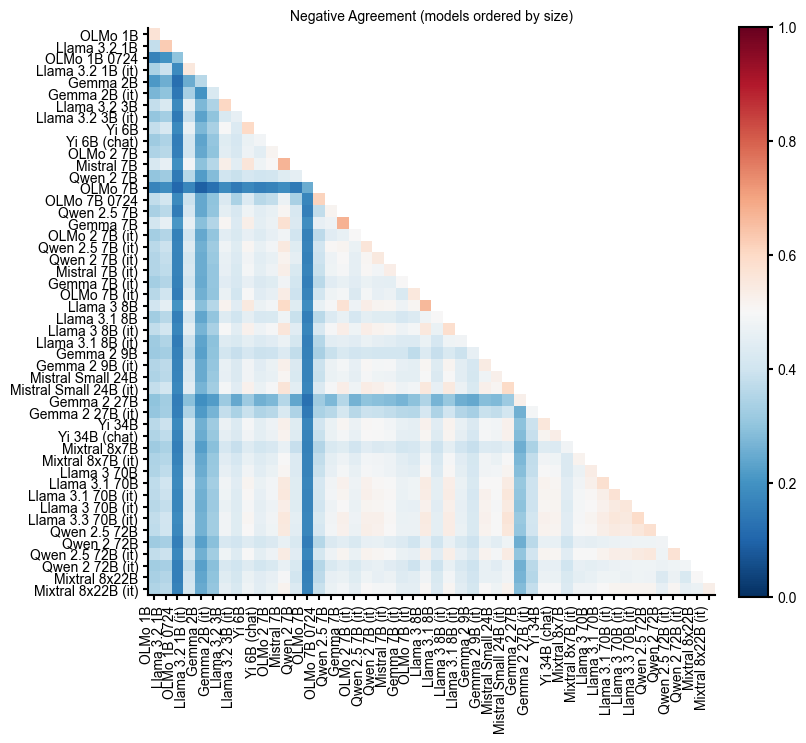

In [18]:
models_sorted = sorted(predictions["ACSIncome"].columns, key=get_size_and_it)

matrix = matrix_pairwise_evals(models_sorted, partial(observed_agreement_wrapper, predictions=predictions['ACSIncome'], fun=get_pairwise_neg_agreement))
#get_pairwise_pos_agreement

plot_agreement_matrix(
    models_sorted,
    matrix,
    cmap="RdBu_r",
    title="Negative Agreement (models ordered by size)",
)

In [19]:
print(models_sorted[2], models_sorted[6]) # both mainly predict 0 
get_pairwise_neg_agreement(predictions['ACSIncome'][models_sorted[2]], predictions['ACSIncome'][models_sorted[6]])

allenai--OLMo-1B-0724-hf meta-llama--Meta-Llama-3.2-3B


0.18341243616701713

When looking only at the fraction of individuals models agree in predicting 0, dark blue regions are either pairs one of the models is an almost-constant-0 predictor or both models are constant 1-predictors and have very few negative predictions to even agree on. 
- **issue**: the base rate (all individuals seems wrong, shouldn't it be only among those that receive at least one negative prediction?)

#### Group by Model Families - Within vs. Between Agreement

In [20]:
from monoculture.analysis.setup import model_families_coarse as model_families
print(model_families)


def create_model_familiy_dict(models):
    # for every model family get the corresponding models
    dict_models_per_family = {
        mf: [
            m
            for m in models_sorted
            if mf in prettify_model_name(key_to_model(m)) or mf.lower() in m.lower()
        ]
        for mf in model_families
    }

    # remove higher-generation models (in case of fine-grained families)
    if "Gemma 2" in model_families:
        dict_models_per_family["Gemma"] = [
            m
            for m in dict_models_per_family["Gemma"]
            if "Gemma 2" not in prettify_model_name(key_to_model(m))
        ]
    for llama_gen in ["Lamma 3.1", "Lamma 3.2", "Lamma 3.3"]:
        if llama_gen in model_families:
            dict_models_per_family["Llama 3"] = [
                m
                for m in dict_models_per_family["Llama 3"]
                if llama_gen not in prettify_model_name(key_to_model(m))
            ]

    # get indices of each model
    dict_modelidx_per_family = {mf: [models_sorted.index(m) for m in mlist] for mf,mlist in dict_models_per_family.items()}
    return dict_models_per_family

dict_models_per_family = create_model_familiy_dict(models_sorted)

['Gemma', 'Llama', 'Mistral', 'OLMo', 'Qwen', 'Yi']


In [21]:
def get_familiy_mean(mf1, mf2, fun):
    models_mf1 = dict_models_per_family[mf1]
    models_mf2 = dict_models_per_family[mf2]
    evals = np.array([fun(m1, m2) for (m1, m2) in itertools.product(models_mf1, models_mf2)])
    return evals.mean()

Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.
Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.


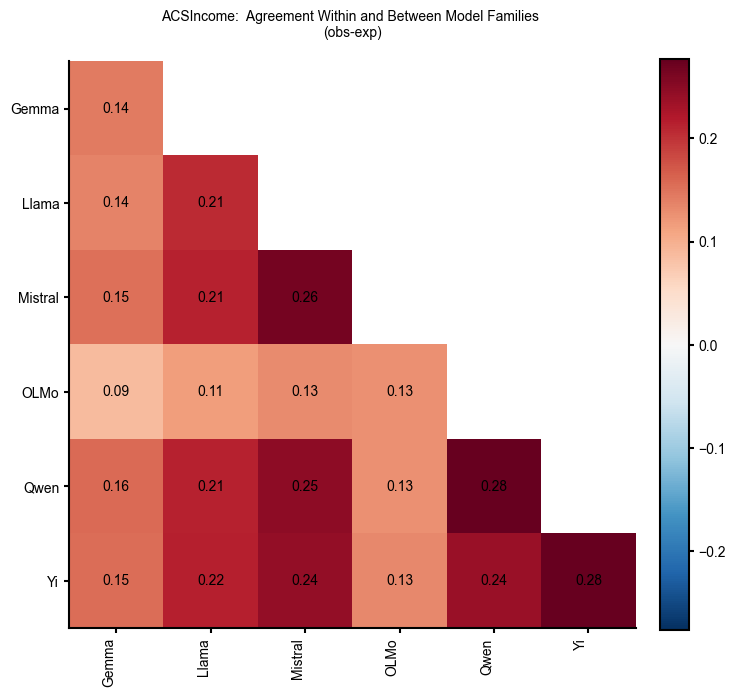

min: 0.09	max: 0.28	median: 0.16


In [22]:
for task in ["ACSIncome"]:
    family_matrix = matrix_pairwise_evals(
        model_families,
        partial(
            get_familiy_mean,
            fun=partial(
                diff_wrapper, evals=evals_0[task], predictions=predictions[task]
            ),
        ),
    )

    cmap_bound = max(
        abs(family_matrix[~family_matrix.isnan()].min()),
        abs(family_matrix[~family_matrix.isnan()].max()),
    )
    plot_agreement_matrix(
        model_families,
        family_matrix,
        cmap="RdBu_r",
        title=f"{task}:  Agreement Within and Between Model Families \n(obs-exp)\n",
        # figsize=(9, 9),
        annotate=True,
        vmin=-cmap_bound,
        vmax=cmap_bound,
    )
    print(
        f"min: {family_matrix[~family_matrix.isnan()].min():.2f}\tmax: {family_matrix[~family_matrix.isnan()].max():.2f}\tmedian: {family_matrix[~family_matrix.isnan()].median():.2f}"
    )

Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.
Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.


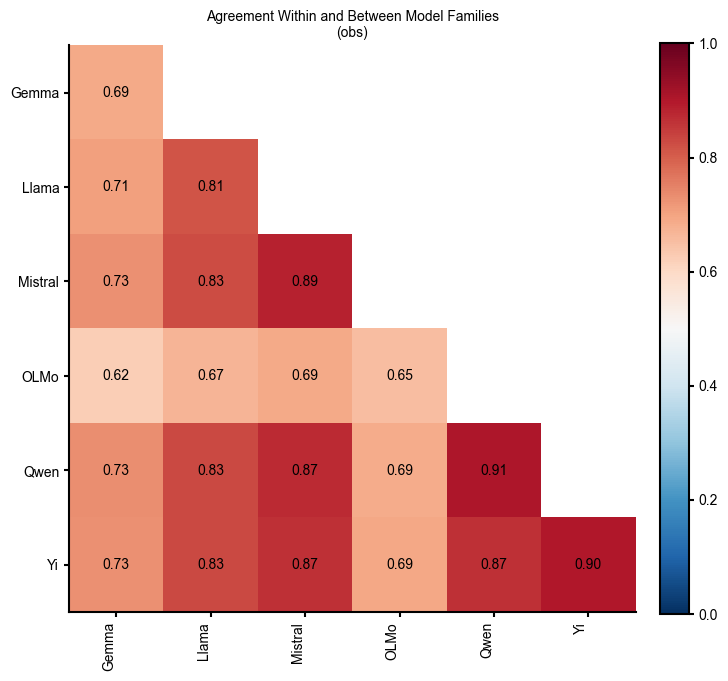

In [23]:
# observed
family_matrix = matrix_pairwise_evals(model_families, partial(get_familiy_mean, fun=partial(observed_agreement_wrapper, predictions=predictions['ACSIncome'])))

plot_agreement_matrix(
    model_families,
    family_matrix,
    cmap="RdBu_r",
    title="Agreement Within and Between Model Families\n(obs)",
    annotate=True,
)

### Load task test data

In [24]:
# Fetch ACS task and dataset
data_dir = Path("./data")
data = {}
for task in TASKS:
    if task in ACS_TASKS:
        acs_task = ACSTaskMetadata.get_task(task)
        acs_dataset_configs = folktexts.benchmark.Benchmark.ACS_DATASET_CONFIGS.copy()
        acs_dataset = ACSDataset.make_from_task(
            task=acs_task, cache_dir=data_dir, **acs_dataset_configs
        )
        X_test, y_test = acs_dataset.get_data_split("test")
        data[task] = (X_test, y_test)
    else:
        brfss_task = TableshiftBRFSSTaskMetadata.get_task(task)
        dataset_configs = folktexts.benchmark.Benchmark.TABLESHIFT_DATASET_CONFIGS.copy()
        ts_dataset = TableshiftBRFSSDataset.make_from_task(
            task=brfss_task, cache_dir=data_dir, **dataset_configs
        )
        X_test, y_test = ts_dataset.get_data_split("test")
        data[task] = (X_test, y_test)

### Reproduce Mania et al. Model similarity Appendix C Fig 4

In [25]:
y_true_income = data['ACSIncome'][1]
predictions_income = risk_score_to_prediction(risk_scores_0["ACSIncome"], binarize_fun=partial(binarize_using_threshold, evals=evals_0['ACSIncome']))
N, M = predictions_income.shape
N

166450

In [26]:
wrongly_classfied = predictions_income.apply(lambda x: (x != y_true_income).astype(int), axis=0).loc[y_true_income==0]
N = wrongly_classfied.shape[0]
#wrongly_classfied.sum(axis=1).sort_values(axis=0, ascending=False)

In [27]:
wrongly_classfied

,allenai--OLMo-1B-hf,meta-llama--Meta-Llama-3.2-1B,allenai--OLMo-1B-0724-hf,meta-llama--Meta-Llama-3.2-1B-Instruct,google--gemma-2b,google--gemma-1.1-2b-it,meta-llama--Meta-Llama-3.2-3B,meta-llama--Meta-Llama-3.2-3B-Instruct,01-ai--Yi-6B,01-ai--Yi-6B-Chat,...,meta-llama--Meta-Llama-3.1-70B,meta-llama--Meta-Llama-3.1-70B-Instruct,meta-llama--Meta-Llama-3-70B-Instruct,meta-llama--Meta-Llama-3.3-70B-Instruct,Qwen--Qwen2.5-72B,Qwen--Qwen2-72B,Qwen--Qwen2.5-72B-Instruct,Qwen--Qwen2-72B-Instruct,mistralai--Mixtral-8x22B-v0.1,mistralai--Mixtral-8x22B-Instruct-v0.1
238351,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2995677,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1924596,0,1,0,0,0,0,1,1,0,1,...,1,1,0,0,0,0,0,0,1,1
2784255,1,0,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1
2809101,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3164791,0,1,0,1,0,0,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1
43637,0,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2494279,1,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2989522,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


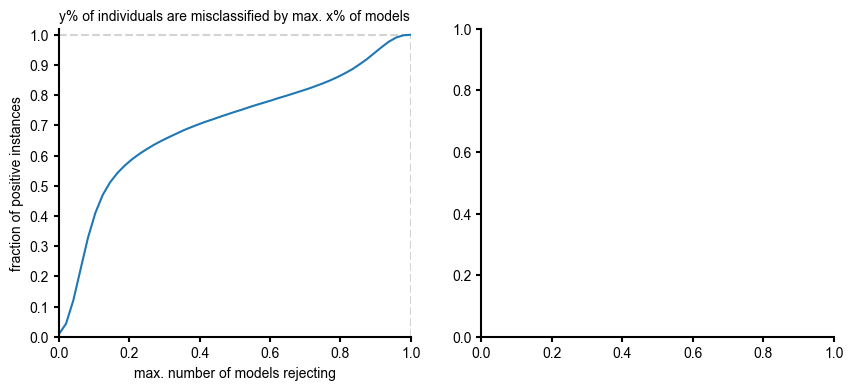

In [28]:
counts_wrongly_classified = [(i, (wrongly_classfied.sum(axis=1) == i).sum()) for i in range(M+1)]
x, y = zip(*counts_wrongly_classified)
fig, ax = plt.subplots(1,2,figsize=(10,4))
#fig.suptitle()
# aboslute number of models
ax[0].set_ylim(0,1.02)
ax[0].set_xlim(0,1.0)
ax[0].set_xlabel('max. number of models rejecting')
ax[0].set_ylabel('fraction of positive instances')
ax[0].set_title('y% of individuals are misclassified by max. x% of models')
ax[0].hlines(y=1.0, xmin=0.0, xmax=1.0, colors='lightgrey', linestyle='dashed')
ax[0].vlines(x=1.0, ymin=0.0, ymax=1.0, colors='lightgrey', linestyle='dashed')
ax[0].plot(np.array(x)/M, np.cumsum(y)/N)
# ax[0].scatter(np.array(x)/M, np.cumsum(y)/N)
ax[0].set_yticks(np.arange(0.0,1.1, 0.1))

# # fraction
# ax[1].set_xlim(0,1.0)
# ax[1].set_ylim(0,1.02)
# ax[1].set_xlabel('min. fraction of models misclassifiying')
# ax[1].set_ylabel('fraction of individuals')
# ax[1].set_title('y% of individuals are misclassified by min. x% of models')
# ax[1].hlines(y=1.0, xmin=0.0, xmax=1.0, colors='lightgrey', linestyle='dashed')
# ax[1].vlines(x=1.0, ymin=0.0, ymax=1.0, colors='lightgrey', linestyle='dashed')
# ax[1].plot(np.array(x)/M, np.cumsum(np.array(y)[::-1])[::-1]/N) # not the same as 1-np.cumsum!
# ax[1].set_yticks(np.arange(0.0,1.1, 0.1))
# plt.show()
    

### How often do models agree in a prediction? (restrict to individuals with label 1)

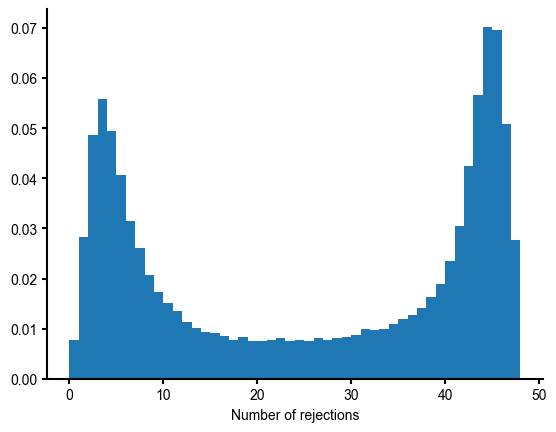

In [29]:
num_samples, num_models = predictions['ACSIncome'].shape
y,x, _ = plt.hist((num_models - predictions['ACSIncome'].sum(axis=1)).values, bins=num_models, weights=np.zeros(shape=(num_samples,))+1./num_samples)
plt.xlabel('Number of rejections')
plt.show()

In [30]:
predictions_pos = {}
for task in TASKS:
    print(task)
    y_true = data[task][1]
    positive_instance_idx = y_true[y_true==1].index
    predictions_pos[task] =  predictions[task].loc[positive_instance_idx] 

ACSIncome
ACSEmployment
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure


#### General Agreement

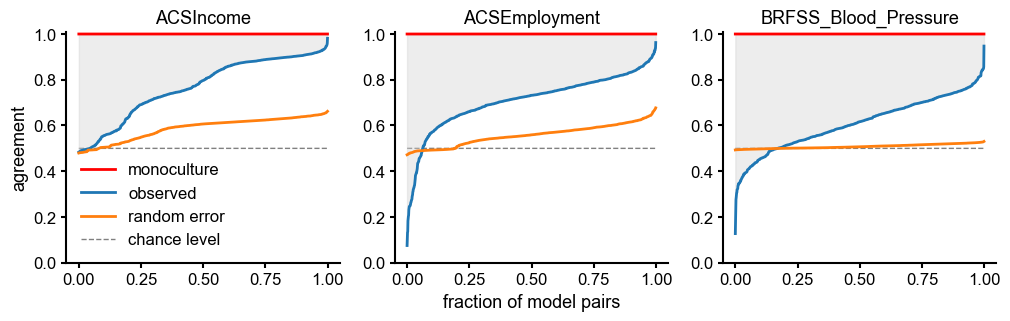

In [71]:
tasks_to_plot = ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']
fig, axs = plt.subplots(1, len(tasks_to_plot), figsize=(4 * len(tasks_to_plot), 3))
sort_by = None
for i, task in enumerate(tasks_to_plot):
    models_sorted = sorted(predictions_pos[task].columns, key=get_size_and_it)
    M = len(models_sorted)

    # agreements without diagonal
    obs_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(observed_agreement_wrapper, predictions=predictions_pos[task]),
    ).fill_diagonal_(torch.nan)
    exp_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        fun=lambda m1, m2: expected_pairwise_agreement(
            evals_0[task][m1]["accuracy"], evals_0[task][m2]["accuracy"]
        ),
    ).fill_diagonal_(torch.nan)

    axs[i] = agreement_line_plot(axs[i], 
                                 obs_agreement_matrix[~obs_agreement_matrix.isnan()], 
                                 exp_agreement_matrix[~exp_agreement_matrix.isnan()], 
                                 title=task)
axs[0].legend()
axs[0].set_ylabel("agreement")
axs[1].set_xlabel("fraction of model pairs")
# fig.suptitle('Pairwise agreement')
plt.savefig('/Users/mgorecki/Documents/2025-04-SAB-meeting/figures/agreement_positive_instances.png')
plt.show()

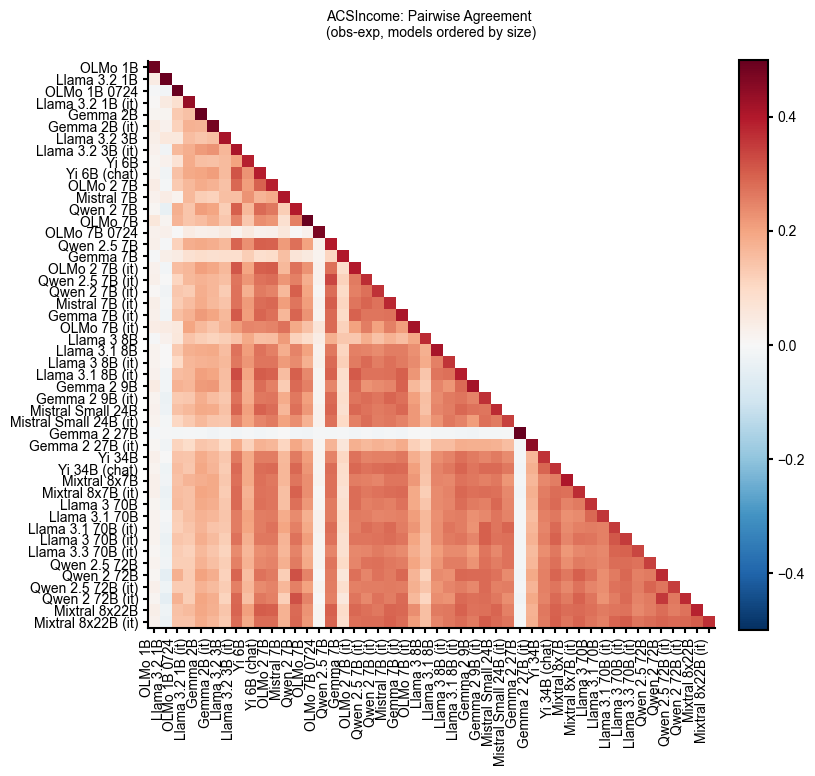

min: -0.04	max: 0.50	median: 0.21


In [32]:
# diff 
for task in ['ACSIncome']:
    models_sorted = sorted(predictions_pos[task].columns, key=get_size_and_it) #sort_by_size_and_family(predictions[task].columns) #
    agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(diff_wrapper, predictions=predictions_pos[task], evals=evals_0[task]),
    )

    cmap_bound = max(
        abs(agreement_matrix[~agreement_matrix.isnan()].min()),
        abs(agreement_matrix[~agreement_matrix.isnan()].max()),
    )
    plot_agreement_matrix(
        models_sorted,
        agreement_matrix,
        cmap="RdBu_r",
        title=f"{task}: Pairwise Agreement \n(obs-exp, models ordered by size)\n",
        # figsize=(9,9),
        annotate=False,
        vmin=-cmap_bound, 
        vmax=cmap_bound,
    )
    print(
        f"min: {agreement_matrix[~agreement_matrix.isnan()].min():.2f}\tmax: {agreement_matrix[~agreement_matrix.isnan()].max():.2f}\tmedian: {agreement_matrix[~agreement_matrix.isnan()].median():.2f}"
    )

#### Agreement on negative predictions

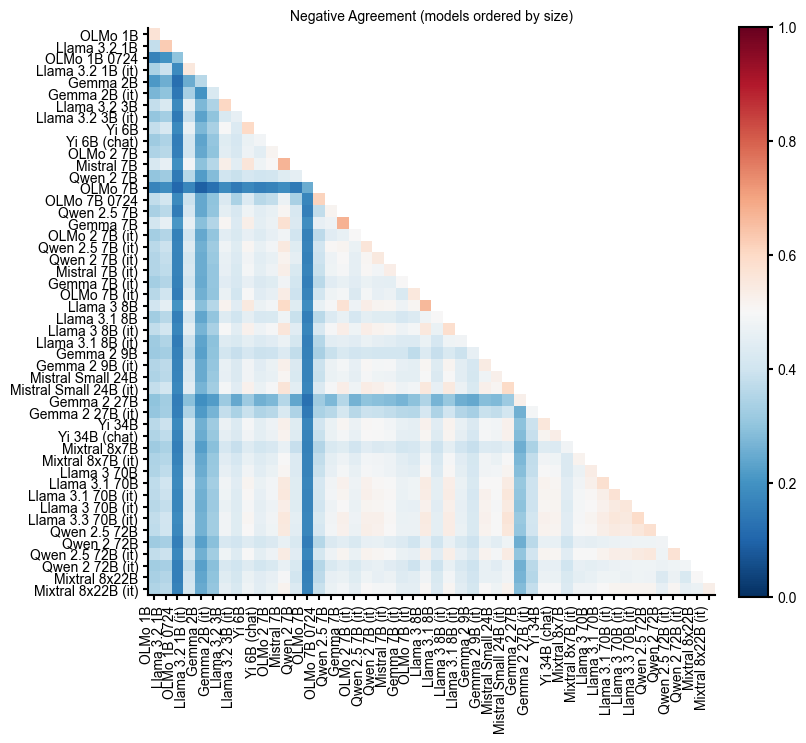

In [34]:
models_sorted = sorted(predictions['ACSIncome'].columns, key=get_size_and_it)

matrix = matrix_pairwise_evals(models_sorted, partial(observed_agreement_wrapper, predictions=predictions['ACSIncome'], fun=get_pairwise_neg_agreement))

plot_agreement_matrix(
    models_sorted,
    matrix,
    cmap="RdBu_r",
    title="Negative Agreement (models ordered by size)",
)

#### Ratio Observed:Expected

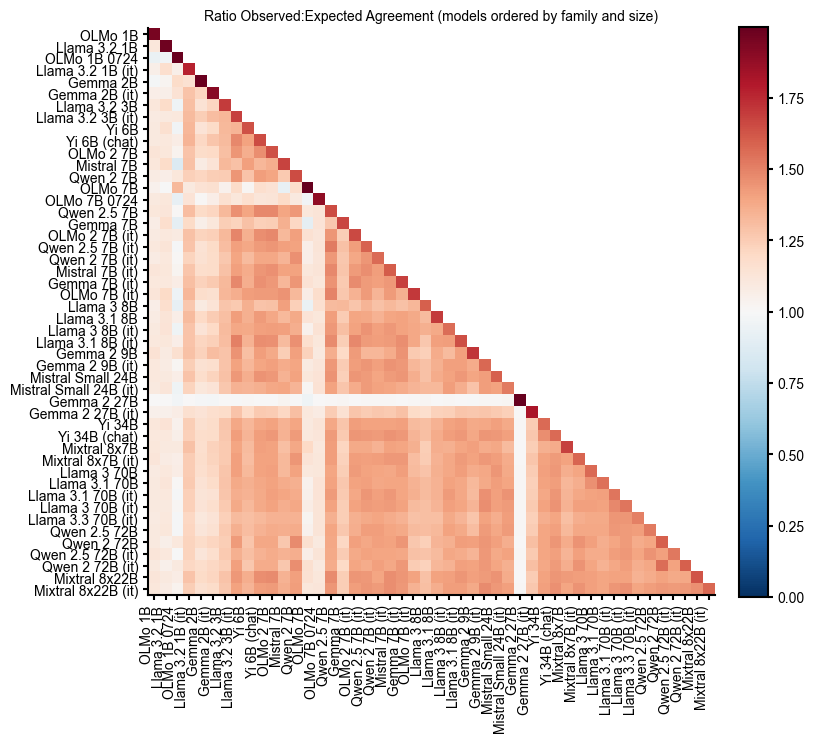

In [37]:
models_sorted = sorted(predictions['ACSIncome'].columns, key=get_size_and_it)

ratio_matrix = matrix_pairwise_evals(models_sorted, partial(ratio_wrapper, predictions=predictions['ACSIncome'], evals = evals_0['ACSIncome']))

plot_agreement_matrix(
    models_sorted,
    ratio_matrix,
    cmap="RdBu_r",
    title="Ratio Observed:Expected Agreement (models ordered by family and size)",
    vmin = 0, #ratio_matrix[~ratio_matrix.isnan()].min(),
    vmax = ratio_matrix[~ratio_matrix.isnan()].max()
)

When calculating the ratio between the observed agreement and what we would expect given the accuracy of each model (i.e. assuming models make their errors at random), we see that model predictions, especially for smaller models are much more aligned than what we would expect at random. 
- values close to 1 mean that model agreement is on a level close to what we would expect at random
- dark blue cells indicate that model pairs agree much less than what would be expected at random (anti-correlated?)
- dark red cells indicate that model pairs agree much more than random

#### Group by Model Families - Within vs. Between Agreement

In [39]:
dict_models_per_family = create_model_familiy_dict(models_sorted)

Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.
Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.


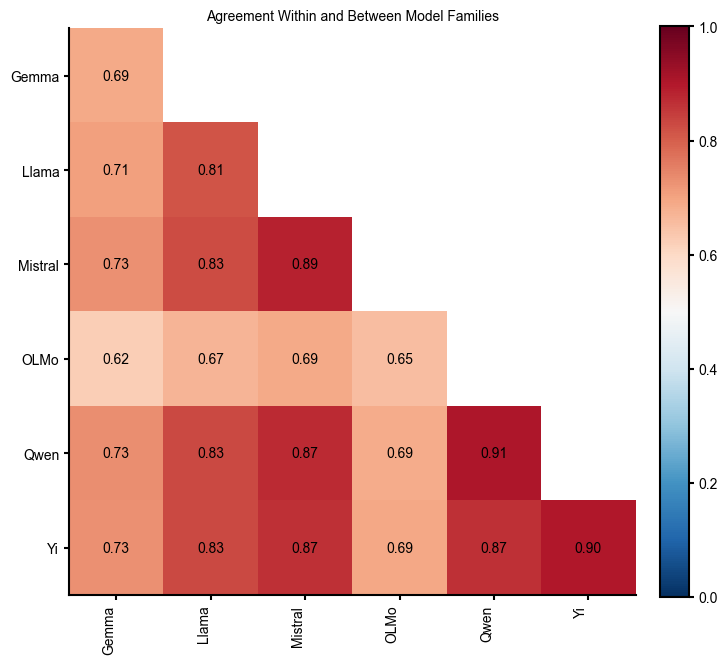

In [40]:
family_matrix = matrix_pairwise_evals(model_families, partial(get_familiy_mean, fun=partial(observed_agreement_wrapper, predictions=predictions['ACSIncome'])))

plot_agreement_matrix(
    model_families,
    family_matrix,
    cmap="RdBu_r",
    title="Agreement Within and Between Model Families",
    annotate=True
)

### How often do models agree in a prediction? (restrict to better than constant)

In [67]:
predictions_filtered = {}
for task in TASKS:
    y_true = data[task][1]
    const_acc = max((y_true==1).sum(), (y_true==0).sum())/y_true.shape[0]
    models_better_const = [m for m in models_sorted if evals_0[task][m]['accuracy'] > const_acc]

    # restrict to positive instances and models better than constant
    predictions_filtered[task] = predictions[task].filter(items=models_better_const)

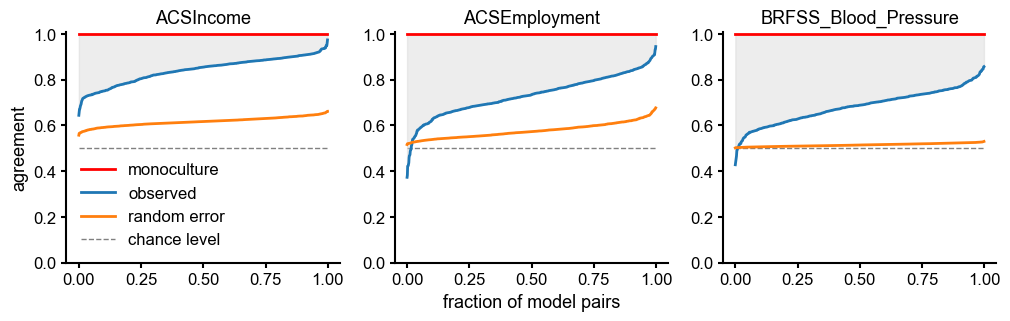

In [72]:
tasks_to_plot = ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']
fig, axs = plt.subplots(1, len(tasks_to_plot), figsize=(4 * len(tasks_to_plot), 3))
sort_by = None
for i, task in enumerate(tasks_to_plot):
    models_sorted = sorted(predictions_filtered[task].columns, key=get_size_and_it)
    M = len(models_sorted)

    # agreements without diagonal
    obs_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(observed_agreement_wrapper, predictions=predictions_filtered[task]),
    ).fill_diagonal_(torch.nan)
    exp_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        fun=lambda m1, m2: expected_pairwise_agreement(
            evals_0[task][m1]["accuracy"], evals_0[task][m2]["accuracy"]
        ),
    ).fill_diagonal_(torch.nan)

    axs[i] = agreement_line_plot(axs[i], 
                                 obs_agreement_matrix[~obs_agreement_matrix.isnan()], 
                                 exp_agreement_matrix[~exp_agreement_matrix.isnan()], 
                                 title=task)
axs[0].legend()
axs[0].set_ylabel("agreement")
axs[1].set_xlabel("fraction of model pairs")
plt.savefig('/Users/mgorecki/Documents/2025-04-SAB-meeting/figures/agreement_better_const.png')

# fig.suptitle('Pairwise agreement')
plt.show()

### How often do models agree in a prediction? (restrict to model better than constant and individuals with label 1)

In [69]:
predictions_pos_filtered = {}
for task in TASKS:
    y_true = data[task][1]
    const_acc = max((y_true==1).sum(), (y_true==0).sum())/y_true.shape[0]
    models_better_const = [m for m in models_sorted if evals_0[task][m]['accuracy'] > const_acc]

    # restrict to positive instances and models better than constant
    positive_instance_idx = y_true[y_true==1].index
    predictions_pos_filtered[task] = predictions[task].loc[positive_instance_idx].filter(items=models_better_const)

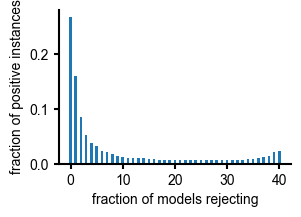

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax = plot_model_agreement_barplot(
    ax,
    predictions_pos_filtered["ACSIncome"],
    y_true=data["ACSIncome"][1][data["ACSIncome"][1] == 1],
    relative_x=False
)
plt.show()

#### General Agreement

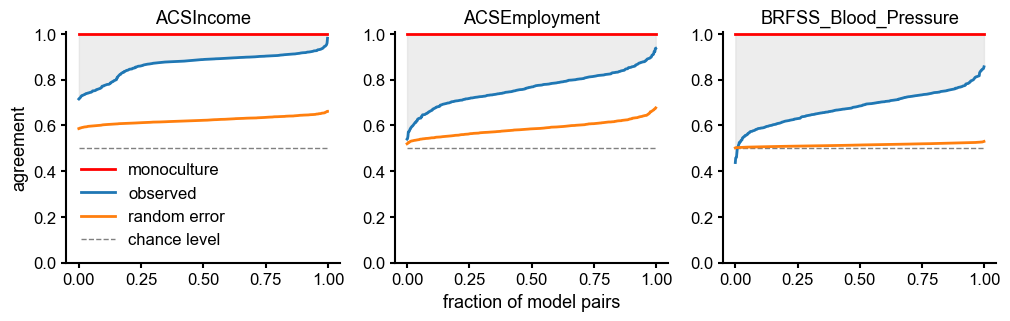

In [73]:
tasks_to_plot = ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']
fig, axs = plt.subplots(1, len(tasks_to_plot), figsize=(4 * len(tasks_to_plot), 3))
sort_by = None
for i, task in enumerate(tasks_to_plot):
    models_sorted = sorted(predictions_pos_filtered[task].columns, key=get_size_and_it)
    M = len(models_sorted)

    # agreements without diagonal
    obs_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(observed_agreement_wrapper, predictions=predictions_pos_filtered[task]),
    ).fill_diagonal_(torch.nan)
    exp_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        fun=lambda m1, m2: expected_pairwise_agreement(
            evals_0[task][m1]["accuracy"], evals_0[task][m2]["accuracy"]
        ),
    ).fill_diagonal_(torch.nan)

    axs[i] = agreement_line_plot(axs[i], 
                                 obs_agreement_matrix[~obs_agreement_matrix.isnan()], 
                                 exp_agreement_matrix[~exp_agreement_matrix.isnan()], 
                                 title=task)
axs[0].legend()
axs[0].set_ylabel("agreement")
axs[1].set_xlabel("fraction of model pairs")
plt.savefig('/Users/mgorecki/Documents/2025-04-SAB-meeting/figures/agreement_positive_instances_better_const.png')

# fig.suptitle('Pairwise agreement')
plt.show()

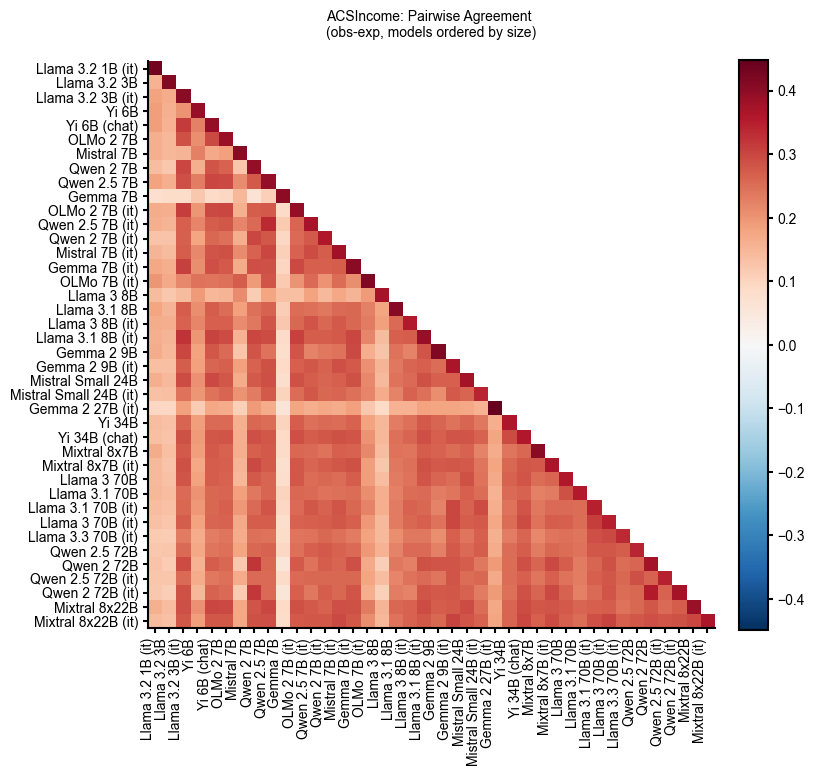

min: 0.05	max: 0.45	median: 0.25


In [ ]:
# diff 
for task in ['ACSIncome']:
    models_sorted = sorted(predictions_pos_filtered[task].columns, key=get_size_and_it) #sort_by_size_and_family(predictions[task].columns) #
    agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(diff_wrapper, predictions=predictions_pos_filtered[task], evals=evals_0[task]),
    )

    cmap_bound = max(
        abs(agreement_matrix[~agreement_matrix.isnan()].min()),
        abs(agreement_matrix[~agreement_matrix.isnan()].max()),
    )
    plot_agreement_matrix(
        models_sorted,
        agreement_matrix,
        cmap="RdBu_r",
        title=f"{task}: Pairwise Agreement \n(obs-exp, models ordered by size)\n",
        # figsize=(9,9),
        annotate=False,
        vmin=-cmap_bound, 
        vmax=cmap_bound,
    )
    print(
        f"min: {agreement_matrix[~agreement_matrix.isnan()].min():.2f}\tmax: {agreement_matrix[~agreement_matrix.isnan()].max():.2f}\tmedian: {agreement_matrix[~agreement_matrix.isnan()].median():.2f}"
    )

#### Agreement on negative predictions

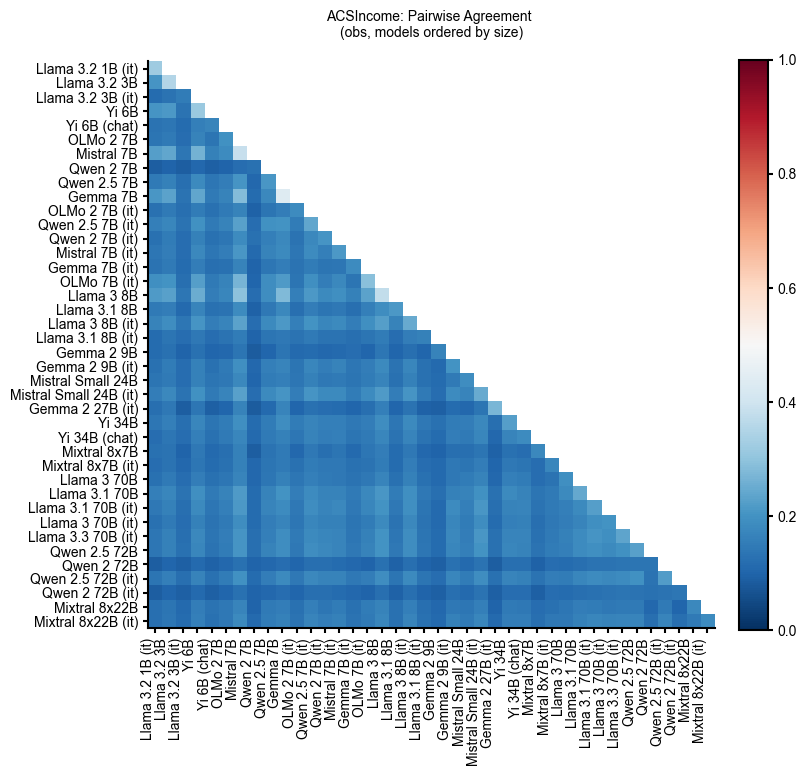

min: 0.08	max: 0.44	median: 0.14


In [ ]:
for task in ['ACSIncome']:
    models_sorted = sorted(predictions_pos_filtered[task].columns, key=get_size_and_it) #sort_by_size_and_family(predictions[task].columns) #
    agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(observed_agreement_wrapper, predictions=predictions_pos_filtered[task],fun=get_pairwise_neg_agreement) # evals=evals_0[task]),
    )

    # cmap_bound = max(
    #     abs(agreement_matrix[~agreement_matrix.isnan()].min()),
    #     abs(agreement_matrix[~agreement_matrix.isnan()].max()),
    # )
    plot_agreement_matrix(
        models_sorted,
        agreement_matrix,
        cmap="RdBu_r",
        title=f"{task}: Pairwise Agreement \n(obs, models ordered by size)\n",
        # figsize=(9,9),
        annotate=False,
    )
    print(
        f"min: {agreement_matrix[~agreement_matrix.isnan()].min():.2f}\tmax: {agreement_matrix[~agreement_matrix.isnan()].max():.2f}\tmedian: {agreement_matrix[~agreement_matrix.isnan()].median():.2f}"
    )

#### Group by Model Families - Within vs. Between Agreement

{'Gemma': 5, 'Llama': 12, 'Mistral': 8, 'OLMo': 3, 'Qwen': 8, 'Yi': 4}

{'Gemma': 5, 'Llama': 12, 'Mistral': 8, 'OLMo': 3, 'Qwen': 8, 'Yi': 4}
Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.
Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.


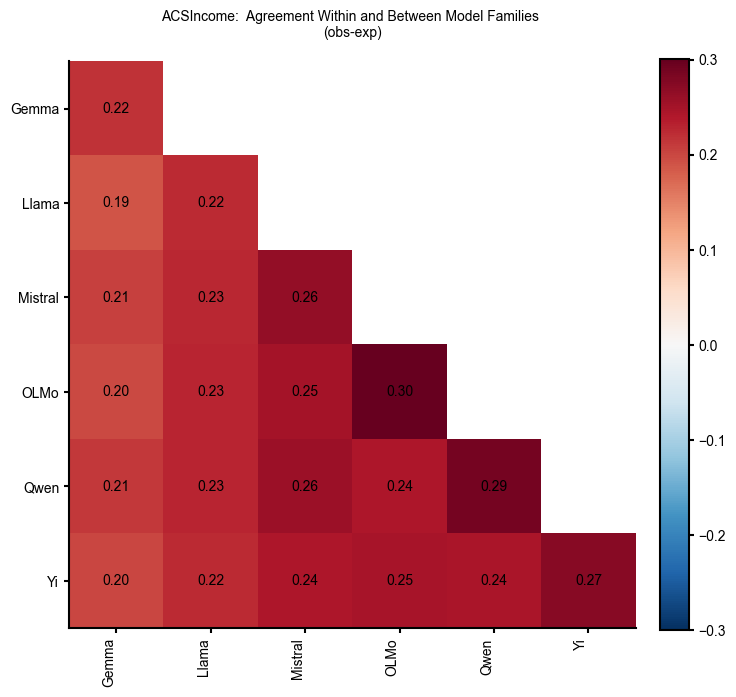

min: 0.19	max: 0.30	median: 0.23
{'Gemma': 4, 'Llama': 12, 'Mistral': 8, 'OLMo': 2, 'Qwen': 8, 'Yi': 4}


AssertionError: Both models must be present as column in predictions

In [ ]:
for task in ["ACSIncome", "ACSEmployment"]:
    print({family: len([m for m in models if m in predictions_pos_filtered[task].columns]) for family, models in dict_models_per_family.items()})
    dict_models_per_family = create_model_familiy_dict(predictions_pos_filtered[task].columns)
    family_matrix = matrix_pairwise_evals(
        model_families,
        partial(
            get_familiy_mean,
            fun=partial(
                diff_wrapper, evals=evals_0[task], predictions=predictions_pos_filtered[task]
            ),
        ),
    )

    cmap_bound = max(
        abs(family_matrix[~family_matrix.isnan()].min()),
        abs(family_matrix[~family_matrix.isnan()].max()),
    )
    plot_agreement_matrix(
        model_families,
        family_matrix,
        cmap="RdBu_r",
        title=f"{task}:  Agreement Within and Between Model Families \n(obs-exp)\n",
        # figsize=(9, 9),
        annotate=True,
        vmin=-cmap_bound,
        vmax=cmap_bound,
    )
    print(
        f"min: {family_matrix[~family_matrix.isnan()].min():.2f}\tmax: {family_matrix[~family_matrix.isnan()].max():.2f}\tmedian: {family_matrix[~family_matrix.isnan()].median():.2f}"
    )